# 01 — Load and Explore Processed Visium Data

This notebook loads a previously processed human IPF Visium `AnnData` object and inspects the spatial, transcriptional, and precomputed latent representations that will be reused throughout the project.

The goal is **downstream spatial analysis**, not reproduction of the original preprocessing pipeline. We therefore reuse the existing scVI representation, UMAP coordinates, cell2location-derived cell abundances, pathway activity scores, NMF factors, and NMF-defined tissue niches.

In [16]:
import scanpy as sc
import pandas as pd
import numpy as np
import squidpy as sq
import warnings
import matplotlib.pyplot as plt

sc.settings.verbosity = 2
sc.set_figure_params(dpi=100, facecolor="white")

## Load the processed AnnData object

In [17]:
# Update this path if your local file is stored elsewhere.
adata = sc.read_h5ad("../data/adata_vis_human_spatial_paper.h5ad")
adata

AnnData object with n_obs × n_vars = 57787 × 12486
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden_25', 'sampleID', 'treatment', 'VisiumSlides', 'technology', 'patient', 'AT0', 'AT1', 'AT2', 'Aberrant basaloid', 'Adventitial fibroblast', 'Alveolar fibroblast', 'Artery', 'B/Plasma', 'Basal', 'Basophil/Mast', 'Bronchial Vessel', 'Capillary', 'Capillary Aerocyte', 'Ciliated', 'Ciliated SFTPB+/SCGB1A1+', 'Dendritic', 'Ionocyte', 'Lymphatic', 'Macrophage C1Q hi', 'Macrophage CHI3L1+/CD9 hi/', 'Macrophage FABP4+', 'Macrophage IL1B+', 'Macrophage LYVE1+', 'Macrophage RETN+/VCAN+', 'Mesothelial', 'Monocyte', 'Mucous', 'Myofibroblast', 'NK', 'Peribronchial fibroblast', 'Pericyte', 'Smooth Muscle', 'T cell', 'TB-SC', 'Vein', 'pDC', 'preTB-SC/RAS', 'Androgen', 'EGFRsignaling', 'Estrogen', 'Hypoxia', 'JAK-STAT', 'MAPK', 'NFkB', 'p53', 'PI3K', 'TGFb', 'TNFa', 'Trail', 'VEGF', 'WNT', 'mean_nUMI_fa

## Dataset overview

The processed object contains spot-level metadata, patient/sample identifiers, precomputed latent representations, spatial coordinates, cell-type abundance estimates, pathway activities, and NMF-derived niche annotations.

In [18]:
print(f"Number of spots: {adata.n_obs:,}")
print(f"Number of genes: {adata.n_vars:,}")

print("\nSamples:")
print(adata.obs["sample"].value_counts())

print("\nTreatment:")
print(adata.obs["treatment"].value_counts())

print("\nPatients:")
print(adata.obs["patient"].value_counts())

print("\nobsm keys:")
print(list(adata.obsm.keys()))

print("\nlayers:")
print(list(adata.layers.keys()))

print("\nuns keys:")
print(list(adata.uns.keys()))

Number of spots: 57,787
Number of genes: 12,486

Samples:
sample
1217_0003_processed_aligned           12107
1217_0001_processed_aligned           10728
1217_0002_processed_aligned            8624
1217_0004_processed_aligned            8206
91_D1_24513-17_IPF_processed_CM        3284
90_C1_RO-730_Healthy_processed_CM      2877
90_A1_H237762_IPF_processed_CM         2793
91_B1_RO-728_Healthy_processed_CM      2448
92_A1_RO-3203_Healthy_processed_CM     2412
91_A1_RO-727_Healthy_processed_CM      2377
92_D1_RO-3736_IPF_processed_CM         1931
Name: count, dtype: int64

Treatment:
treatment
IPF        30843
Healthy    26944
Name: count, dtype: int64

Patients:
patient
Donor_IPF_2        15391
Donor_IPF_1        13521
Donor_Control_2    11083
Donor_Control_1    11001
Donor_Control_4     2448
Donor_Control_3     2412
Donor_IPF_3         1931
Name: count, dtype: int64

obsm keys:
['X_pca', 'X_scVI', 'X_umap', '_scvi_extra_continuous_covs', 'means_cell_abundance_w_sf', 'mlm_estimate', 'mlm_

In [19]:
sample_summary = (
    adata.obs
    .groupby(["sample", "patient", "treatment"], observed=True)
    .size()
    .reset_index(name="n_spots")
)

sample_summary

,sample,patient,treatment,n_spots
0,90_A1_H237762_IPF_processed_CM,Donor_IPF_1,IPF,2793
1,90_C1_RO-730_Healthy_processed_CM,Donor_Control_2,Healthy,2877
2,91_A1_RO-727_Healthy_processed_CM,Donor_Control_1,Healthy,2377
3,91_B1_RO-728_Healthy_processed_CM,Donor_Control_4,Healthy,2448
4,91_D1_24513-17_IPF_processed_CM,Donor_IPF_2,IPF,3284
5,92_D1_RO-3736_IPF_processed_CM,Donor_IPF_3,IPF,1931
6,92_A1_RO-3203_Healthy_processed_CM,Donor_Control_3,Healthy,2412
7,1217_0001_processed_aligned,Donor_IPF_1,IPF,10728
8,1217_0002_processed_aligned,Donor_Control_1,Healthy,8624
9,1217_0003_processed_aligned,Donor_IPF_2,IPF,12107


## Derived cell-type, pathway, and NMF features

The object already contains 37 cell2location-derived cell-population abundance features, 14 pathway scores, precomputed NMF factor columns, and a final `Niche_NMF` label.

In [20]:
cell_types = [
    "AT0", "AT1", "AT2",
    "Aberrant basaloid",
    "Adventitial fibroblast",
    "Alveolar fibroblast",
    "Artery",
    "B/Plasma",
    "Basal",
    "Basophil/Mast",
    "Bronchial Vessel",
    "Capillary",
    "Capillary Aerocyte",
    "Ciliated",
    "Ciliated SFTPB+/SCGB1A1+",
    "Dendritic",
    "Ionocyte",
    "Lymphatic",
    "Macrophage C1Q hi",
    "Macrophage CHI3L1+/CD9 hi/",
    "Macrophage FABP4+",
    "Macrophage IL1B+",
    "Macrophage LYVE1+",
    "Macrophage RETN+/VCAN+",
    "Mesothelial",
    "Monocyte",
    "Mucous",
    "Myofibroblast",
    "NK",
    "Peribronchial fibroblast",
    "Pericyte",
    "Smooth Muscle",
    "T cell",
    "TB-SC",
    "Vein",
    "pDC",
    "preTB-SC/RAS"
]

pathways = [
    "Androgen",
    "EGFRsignaling",
    "Estrogen",
    "Hypoxia",
    "JAK-STAT",
    "MAPK",
    "NFkB",
    "p53",
    "PI3K",
    "TGFb",
    "TNFa",
    "Trail",
    "VEGF",
    "WNT"
]

nmf_factor_cols = [
    c for c in adata.obs.columns
    if c.startswith("mean_nUMI_factorsfact_")
]

print("Cell types:", len(cell_types))
print("Pathways:", len(pathways))
print("NMF factor columns:", len(nmf_factor_cols))
print("Niche labels:", adata.obs["Niche_NMF"].nunique())

Cell types: 37
Pathways: 14
NMF factor columns: 10
Niche labels: 8


## Precomputed representations

- `X_scVI`: scVI latent representation
- `X_umap`: precomputed UMAP coordinates
- `spatial`: Visium tissue coordinates
- `q05_cell_abundance_w_sf`: cell2location-derived abundance estimates
- `mlm_estimate`: pathway activity estimates

These representations are reused rather than recomputed.

In [21]:
for key in [
    "X_scVI",
    "X_umap",
    "spatial",
    "q05_cell_abundance_w_sf",
    "mlm_estimate"
]:
    if key in adata.obsm:
        print(f"{key}: {adata.obsm[key].shape}")

X_scVI: (57787, 10)
X_umap: (57787, 2)
spatial: (57787, 2)
q05_cell_abundance_w_sf: (57787, 37)
mlm_estimate: (57787, 14)


## Explore the existing UMAP embedding

The UMAP and Leiden clustering are reused from the processed object; they are not recomputed in this demo.

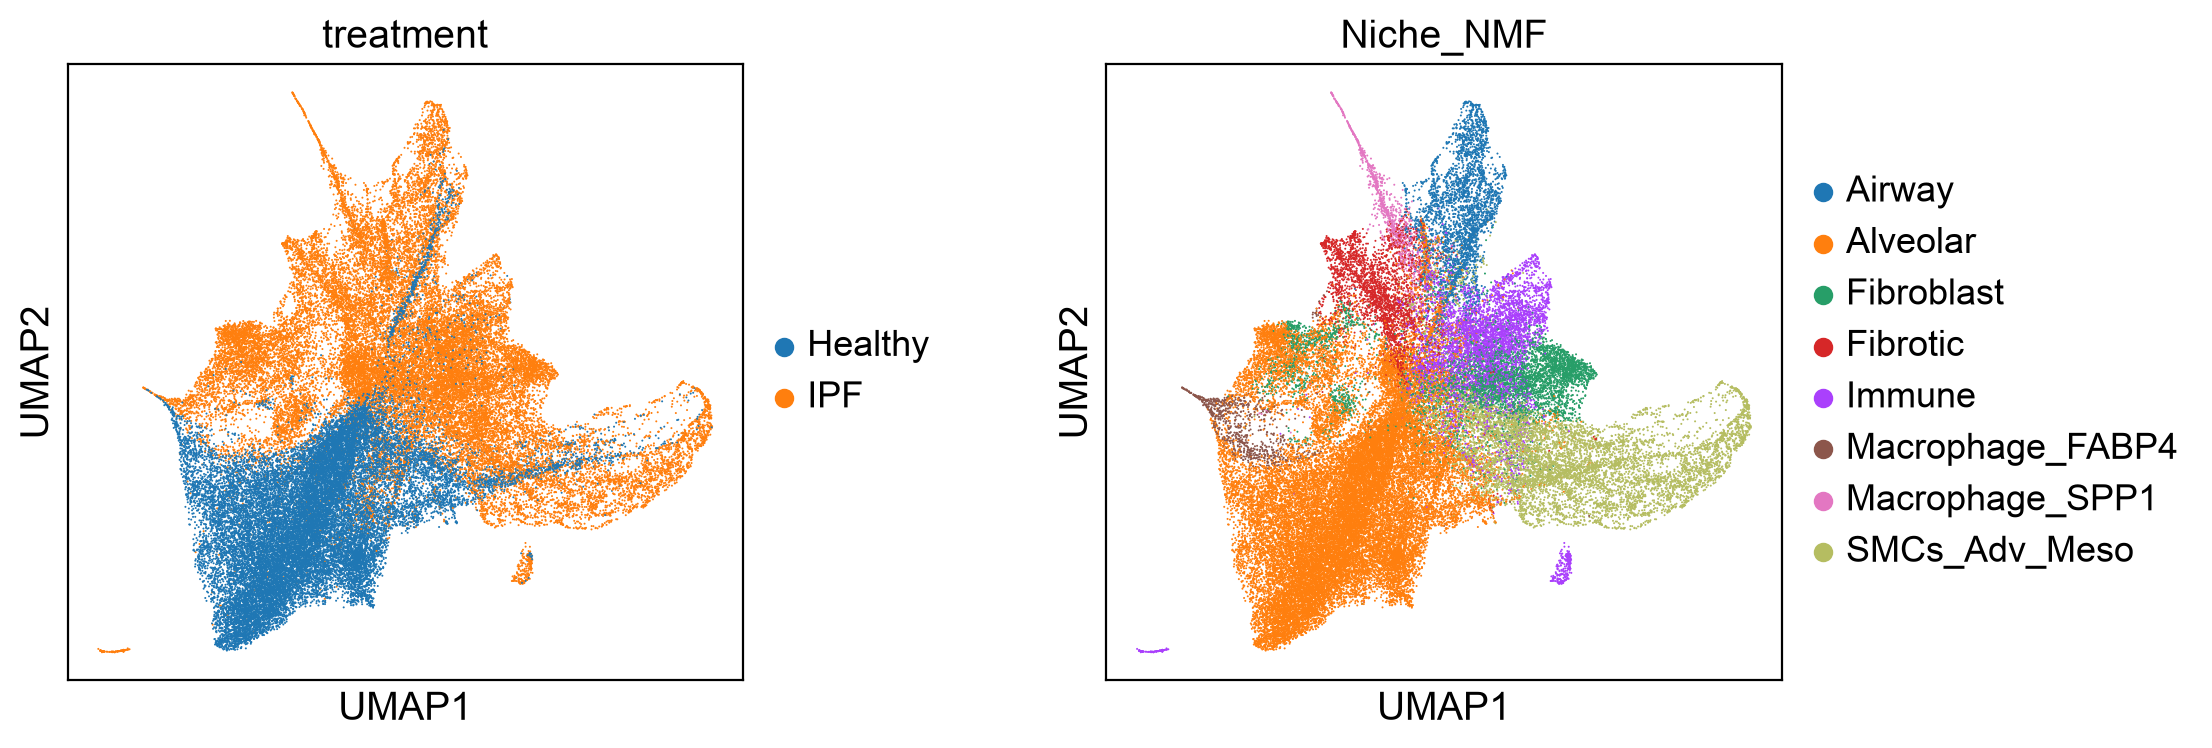

In [22]:
sc.pl.umap(
    adata,
    color=["treatment", "Niche_NMF"],
    wspace=0.4
)

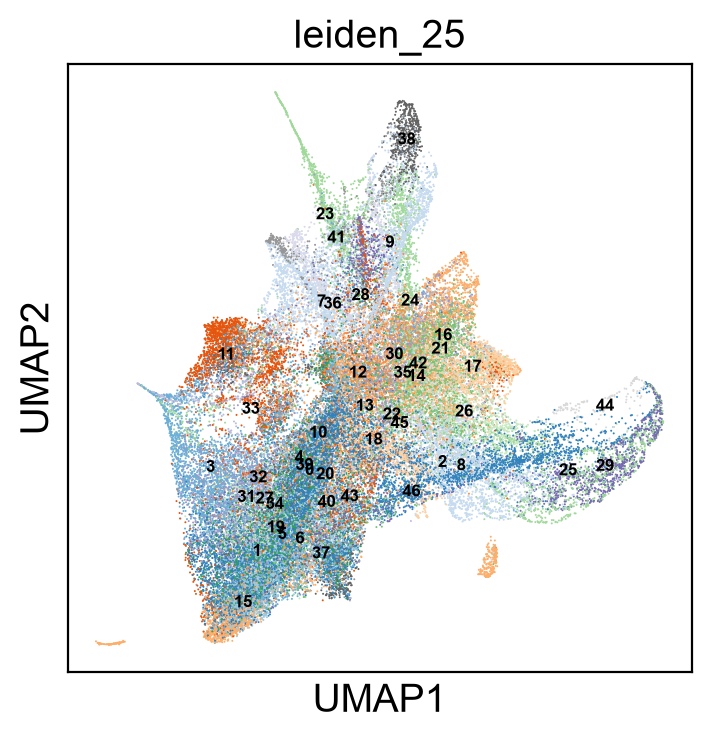

In [23]:
sc.pl.umap(
    adata,
    color="leiden_25",
    legend_loc="on data",
    legend_fontsize=6
)

## Inspect one representative IPF section

In [24]:
sample = "90_A1_H237762_IPF_processed_CM"

adata_sample = adata[
    adata.obs["sample"] == sample
].copy()

adata_sample

AnnData object with n_obs × n_vars = 2793 × 12486
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden_25', 'sampleID', 'treatment', 'VisiumSlides', 'technology', 'patient', 'AT0', 'AT1', 'AT2', 'Aberrant basaloid', 'Adventitial fibroblast', 'Alveolar fibroblast', 'Artery', 'B/Plasma', 'Basal', 'Basophil/Mast', 'Bronchial Vessel', 'Capillary', 'Capillary Aerocyte', 'Ciliated', 'Ciliated SFTPB+/SCGB1A1+', 'Dendritic', 'Ionocyte', 'Lymphatic', 'Macrophage C1Q hi', 'Macrophage CHI3L1+/CD9 hi/', 'Macrophage FABP4+', 'Macrophage IL1B+', 'Macrophage LYVE1+', 'Macrophage RETN+/VCAN+', 'Mesothelial', 'Monocyte', 'Mucous', 'Myofibroblast', 'NK', 'Peribronchial fibroblast', 'Pericyte', 'Smooth Muscle', 'T cell', 'TB-SC', 'Vein', 'pDC', 'preTB-SC/RAS', 'Androgen', 'EGFRsignaling', 'Estrogen', 'Hypoxia', 'JAK-STAT', 'MAPK', 'NFkB', 'p53', 'PI3K', 'TGFb', 'TNFa', 'Trail', 'VEGF', 'WNT', 'mean_nUMI_fac

In [25]:
print("Spatial library IDs:")
print(list(adata.uns["spatial"].keys()))

Spatial library IDs:
['1217_0001_processed_aligned', '1217_0002_processed_aligned', '1217_0003_processed_aligned', '1217_0004_processed_aligned', '90_A1_H237762_IPF_processed_CM', '90_C1_RO-730_Healthy_processed_CM', '91_A1_RO-727_Healthy_processed_CM', '91_B1_RO-728_Healthy_processed_CM', '91_D1_24513-17_IPF_processed_CM', '92_A1_RO-3203_Healthy_processed_CM', '92_D1_RO-3736_IPF_processed_CM']


## Spatial distribution of NMF-defined tissue niches

`Niche_NMF` summarizes spatially organized multicellular microenvironments derived from cell2location-based cell abundance profiles. Later notebooks focus on the `Fibrotic` niche.

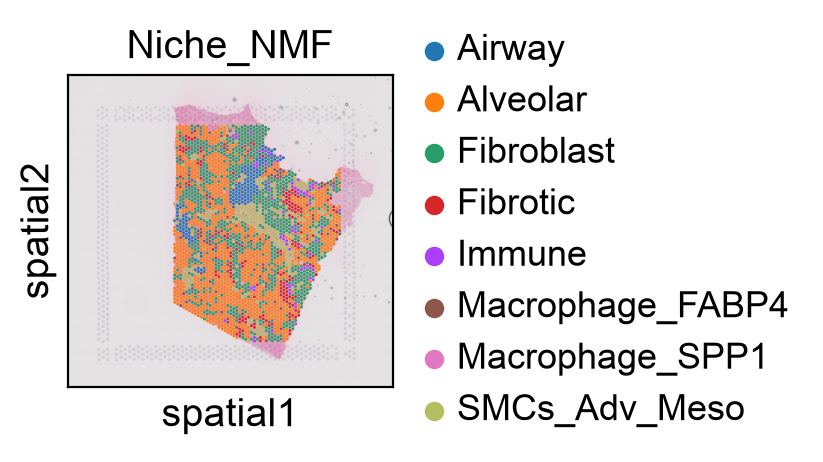

In [26]:

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=r"The method obs_vector is deprecated.*",
        category=FutureWarning,
    )

    sq.pl.spatial_scatter(
        adata_sample,
        color="Niche_NMF",
        library_id=sample,
        size=1.3,
    )

## Representative spatial gene-expression patterns

A small set of fibrosis-associated and alveolar markers is shown as a basic biological sanity check. Systematic spatial gene/pathway analyses are reserved for later notebooks.

In [27]:
genes = [
    "COL1A1",
    "CTHRC1",
    "POSTN",
    "SFTPC",
    "AGER"
]

genes = [g for g in genes if g in adata.var_names]
genes

['COL1A1', 'CTHRC1', 'POSTN', 'SFTPC', 'AGER']

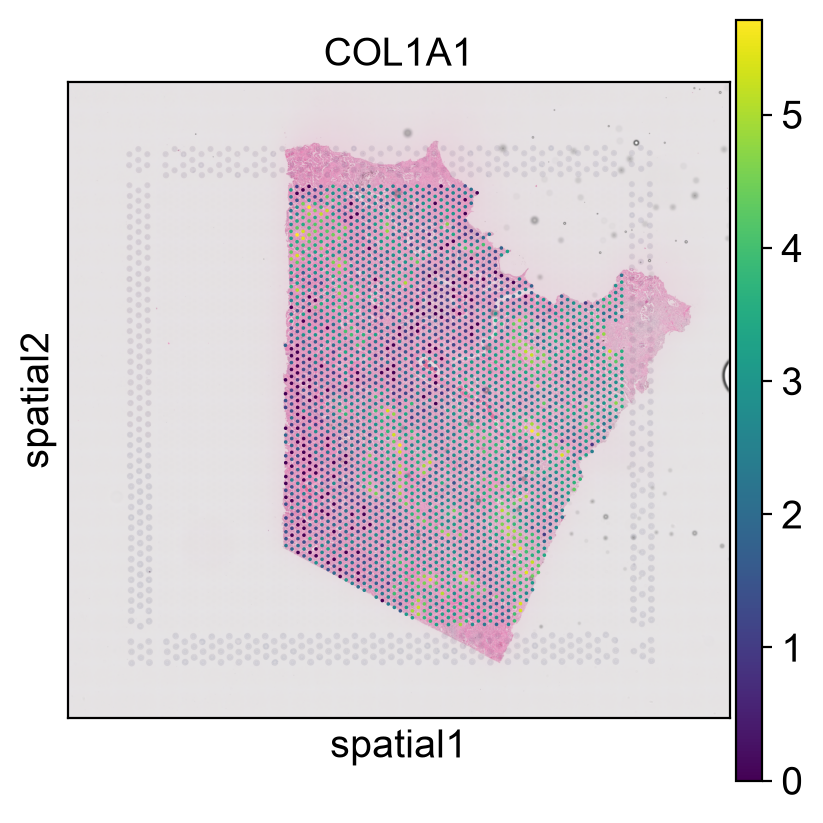

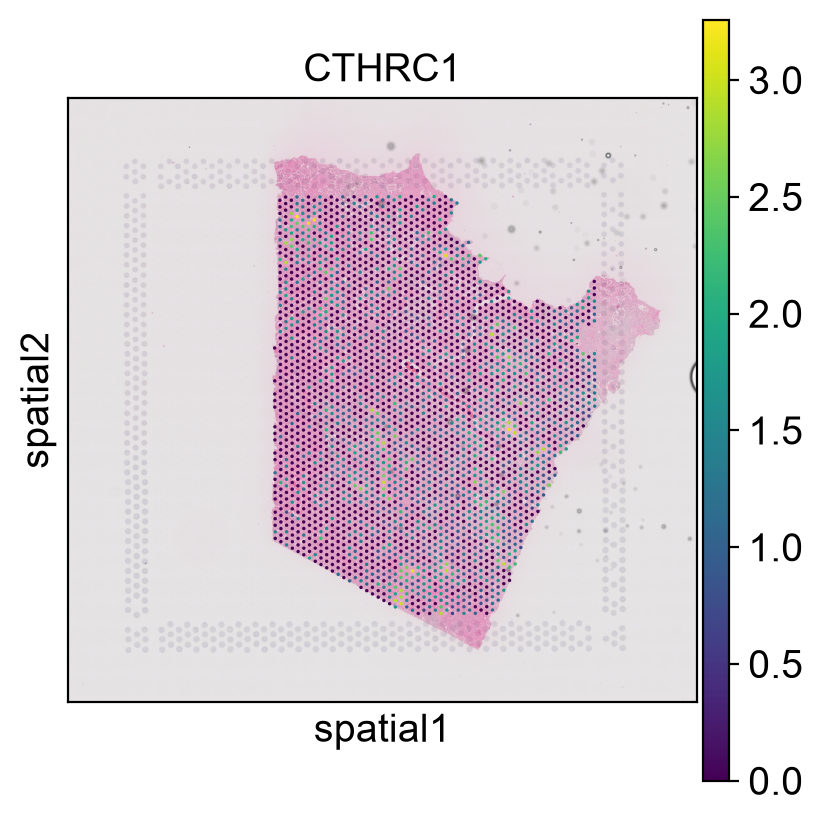

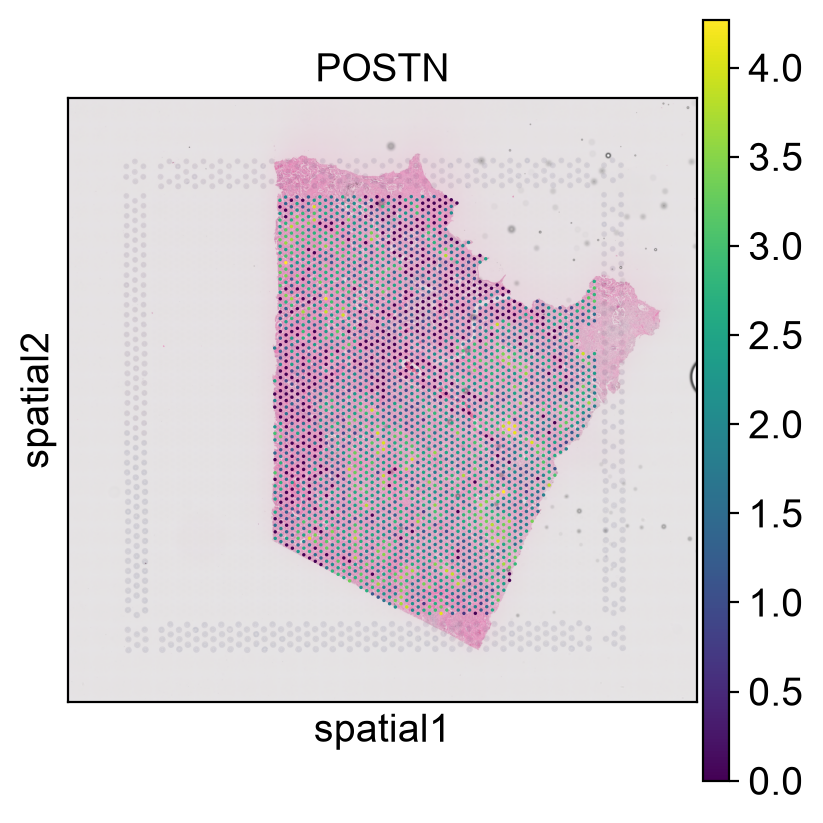

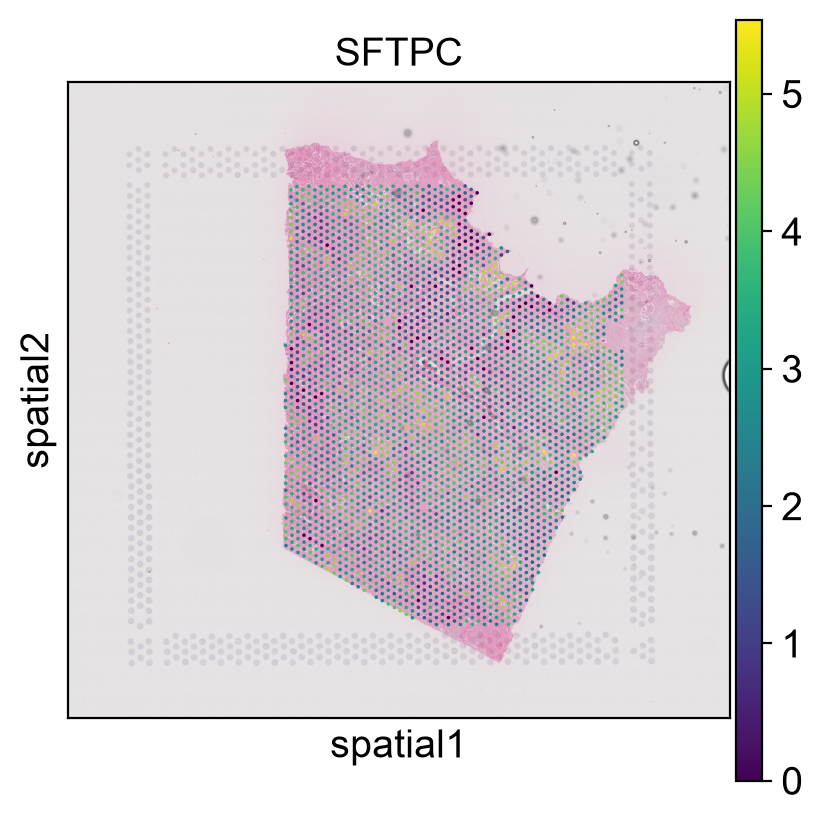

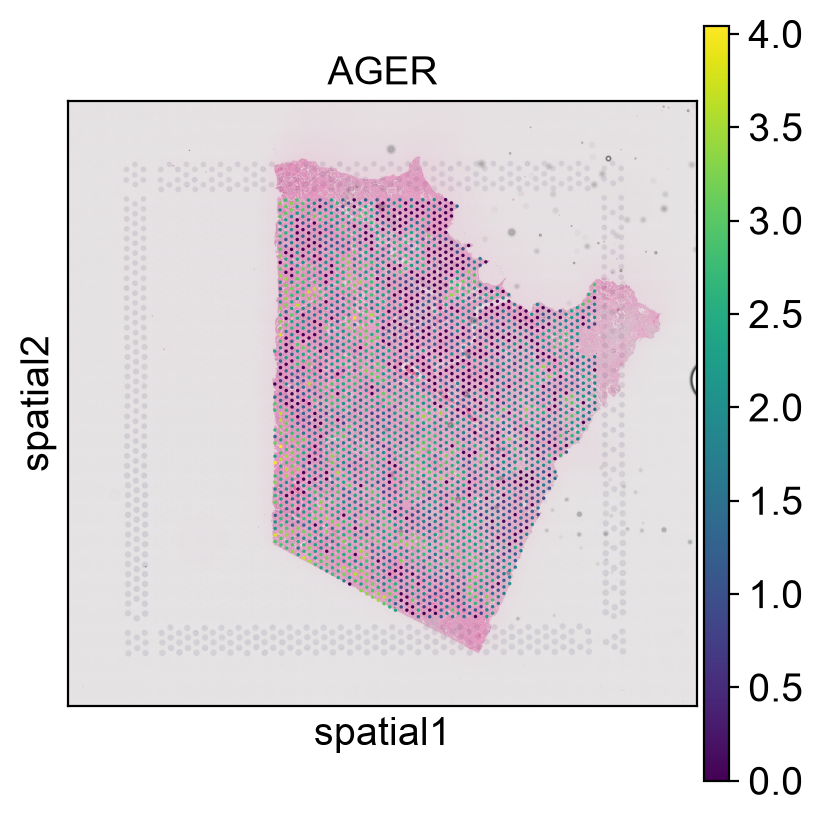

In [28]:

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=r"The method obs_vector is deprecated.*",
        category=FutureWarning,
    )

    for gene in genes:
     sq.pl.spatial_scatter(
        adata_sample,
        color=gene,
        use_raw=False,
        library_id=sample,
        size=0.8,
        title=gene,
    )



## Representative spatial pathway-activity patterns

MLM-derived activity scores for representative fibrosis-associated signaling pathways are visualized across the same tissue section. Positive and negative values indicate the inferred direction of pathway activity relative to the model baseline.

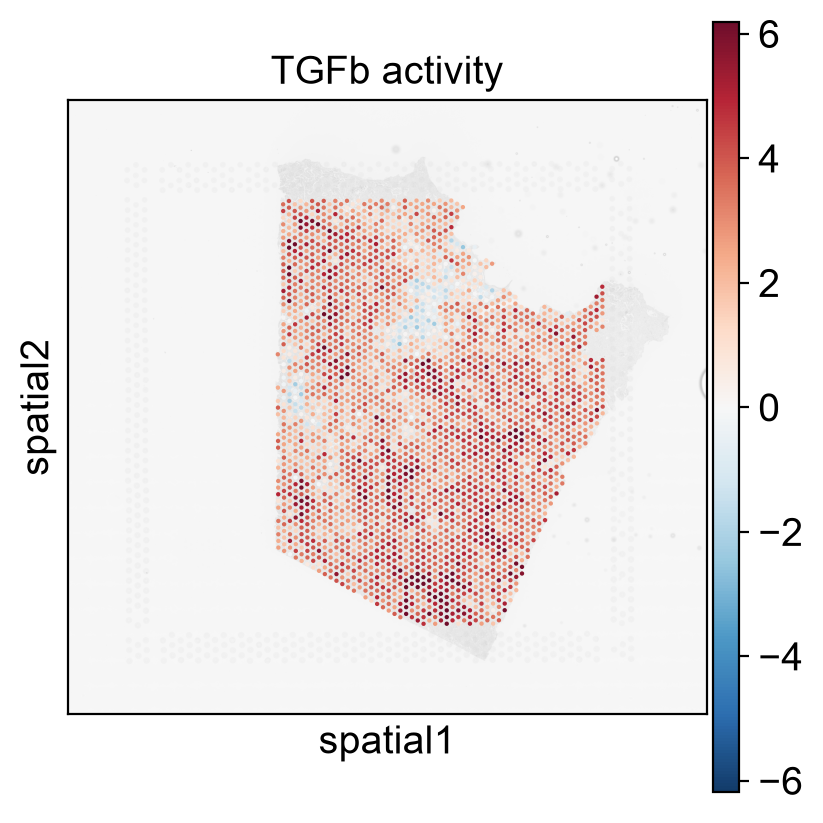

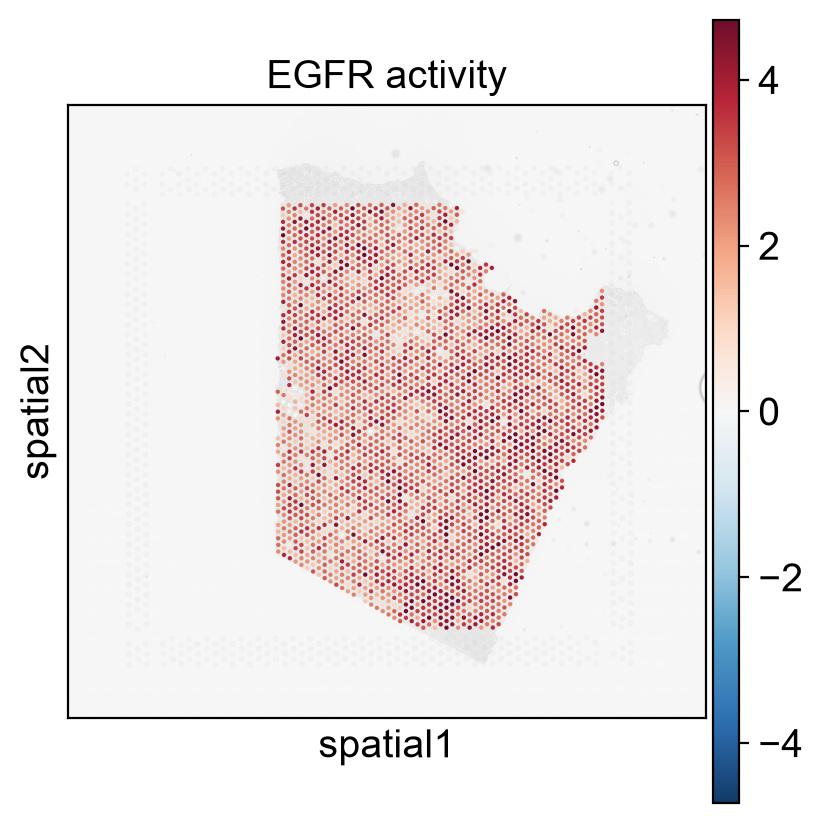

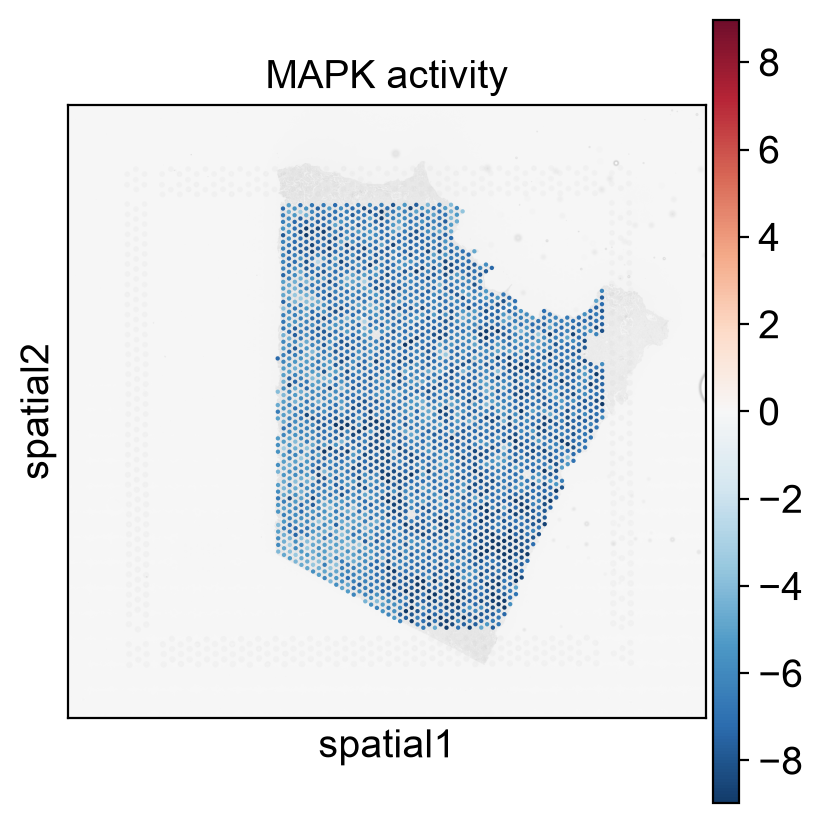

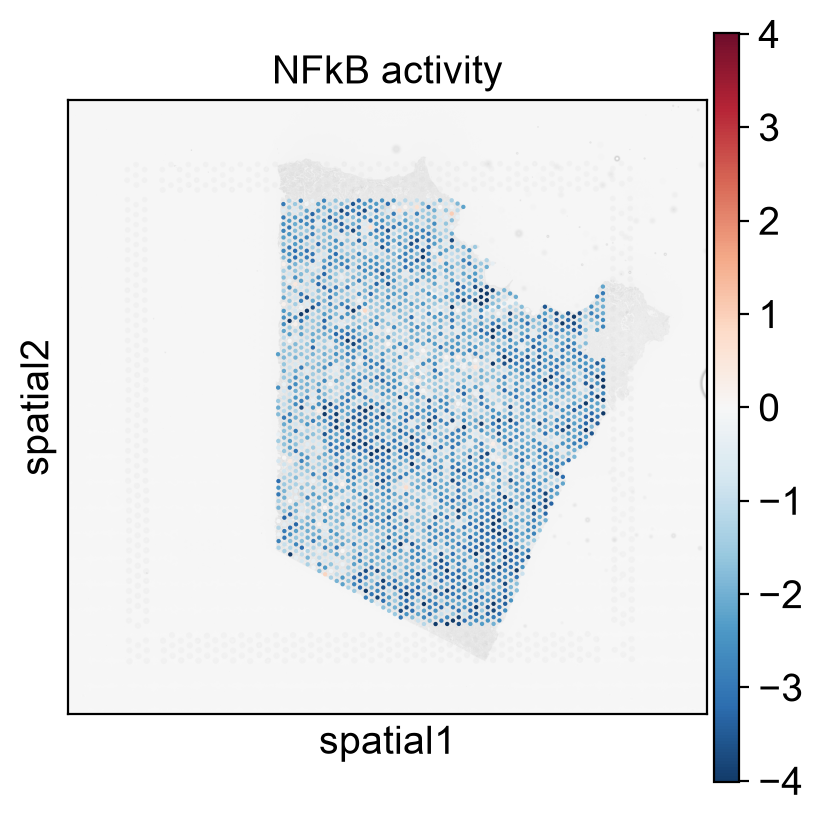

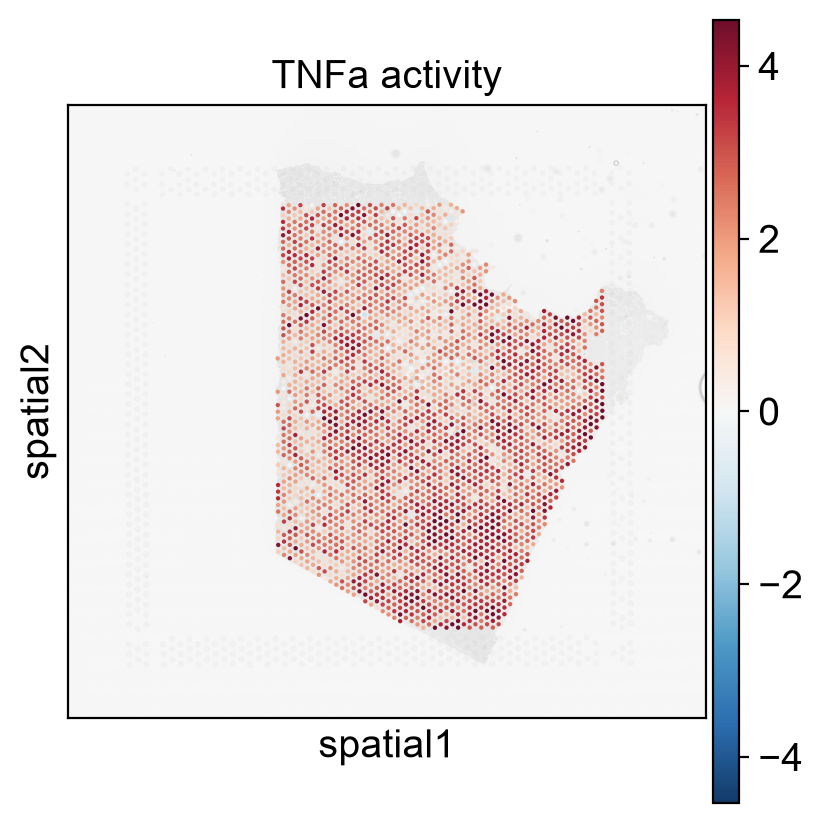

In [29]:
pathway_scores = adata_sample.obsm["mlm_estimate"]

pathways = ["TGFb", "EGFR", "MAPK", "NFkB", "TNFa"]
pathways = [pathway for pathway in pathways if pathway in pathway_scores.columns]

for pathway in pathways:
    adata_sample.obs[f"MLM_{pathway}"] = pathway_scores[pathway].to_numpy()

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=r"The method obs_vector is deprecated.*",
        category=FutureWarning,
    )

    for pathway in pathways:
        column = f"MLM_{pathway}"
        values = adata_sample.obs[column].to_numpy()
        limit = max(np.nanpercentile(np.abs(values), 98), np.finfo(float).eps)

        sq.pl.spatial_scatter(
            adata_sample,
            color=column,
            library_id=sample,
            size=1.0,
            alpha=0.95,
            img_cmap="gray",
            img_alpha=0.25,
            cmap="RdBu_r",
            vmin=-limit,
            vmax=limit,
            title=f"{pathway} activity",
        )

## Compact AnnData architecture summary

In [30]:
print("AnnData structure")
print("------------------")
print("X:", adata.shape)
print("obs:", adata.obs.shape)
print("var:", adata.var.shape)

print("\nSelected obsm entries:")
for key in adata.obsm.keys():
    try:
        print(f"{key}: {adata.obsm[key].shape}")
    except Exception:
        pass

AnnData structure
------------------
X: (57787, 12486)
obs: (57787, 76)
var: (12486, 10)

Selected obsm entries:
X_pca: (57787, 50)
X_scVI: (57787, 10)
X_umap: (57787, 2)
_scvi_extra_continuous_covs: (57787, 1)
means_cell_abundance_w_sf: (57787, 37)
mlm_estimate: (57787, 14)
mlm_pvals: (57787, 14)
q05_cell_abundance_w_sf: (57787, 37)
q95_cell_abundance_w_sf: (57787, 37)
spatial: (57787, 2)
stds_cell_abundance_w_sf: (57787, 37)


## Summary

This notebook establishes the processed Visium dataset used throughout the project. The object contains:

- spatially resolved gene expression,
- integrated scVI embeddings,
- cell2location-derived abundance estimates for 37 cell populations,
- pathway activity scores,
- precomputed NMF factors,
- NMF-defined tissue niche labels,
- and spatial image/coordinate metadata.

The next notebook, `02_cell2location_nmf_niches.ipynb`, focuses on the cell2location abundance matrix and the NMF-defined multicellular tissue niches.